# CLIP zero-shot Evaluation
This short notebook implements the dataset split into base and novel categories (see project assignment) and runs the zero-shot evaluation with CLIP.
Feel free to copy the code contained in this notebook or to directly use this notebook as starting point for you project.

In [1]:
# we need to install clip as it is not pre-installed
# you are also free to use open_clip which provide more models
# https://github.com/mlfoundations/open_clip
%pip install openai_clip


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torchvision
import torch.nn as nn
import clip
from tqdm import tqdm

## Dataset Loading
Let's get the data directly from torchvision as we have seen during labs.

In [3]:
def get_data(data_dir="./data", transform=None):
    """Load Flowers102 train, validation and test sets.
    Args:
        data_dir (str): Directory where the dataset will be stored.
        transform (torch.Compose)
    Returns:
        tuple: A tuple containing the train, validation, and test sets.
    """
    train = torchvision.datasets.Flowers102(root=data_dir, split="train", download=True, transform=transform)
    val = torchvision.datasets.Flowers102(root=data_dir, split="val", download=True, transform=transform)
    test = torchvision.datasets.Flowers102(root=data_dir, split="test", download=True, transform=transform)
    return train, val, test

## Base and Novel categories
To split in base and novel categories we list all dataset classes, and count their number (we already know it's 102 but let's do it properly).
Then, we just allocate the first half to base categories and the remaining half to novel ones.
We can do this because we are simulating a real world application, but keep in mind this will not happen out there!

In [4]:
def base_novel_categories(dataset):
    # set returns the unique set of all dataset classes
    all_classes = set(dataset._labels)
    # and let's count them
    num_classes = len(all_classes)

    # here list(range(num_classes)) returns a list from 0 to num_classes - 1
    # then we slice the list in half and generate base and novel category lists
    base_classes = list(range(num_classes))[:num_classes//2]
    novel_classes = list(range(num_classes))[num_classes//2:]
    return base_classes, novel_classes

## Inspect Classes
Let's now visualize which are the base and novel classes.
To do so, we first get a dummy test set (without augmentations) as we are just interested in the dataset labels. Then, we split it useing `base_novel_categories`.
Finally, we use the hard-coded CLASS_NAMES to print the class in natural language.

> Note: the list of class names was only recently added to `torchvision.datasets.Flowers102`. To avoid useless errors that can occour to you, we decided to also provide such a list.

In [ ]:
_, _, tmp_test = get_data()
base_classes, novel_classes = base_novel_categories(tmp_test)
CLASS_NAMES = [['pink primrose', 'pink evening primrose'], ['hard-leaved pocket orchid', 'silver slipper orchid'],
               ['canterbury bells', 'campanula medium'], ['sweet pea', 'lathyrus odoratus'], ['english marigold', 'calendula'],
               ['tiger lily'], ['moon orchid'], ['bird of paradise'], ['monkshood'], ['globe thistle'], ['snapdragon'],
               ["colt's foot", 'coltsfoot'], ['king protea'], ['spear thistle'], ['yellow iris'], ['globe-flower', 'trollius'],
               ['purple coneflower'], ['peruvian lily'], ['balloon flower', 'chinese bellflower'], ['giant white arum lily'],
               ['fire lily'], ['pincushion flower'], ['fritillary'], ['red ginger'], ['grape hyacinth'], ['corn poppy'],
               ['prince of wales feathers', 'amaranthus hypochondriacus'], ['stemless gentian'], ['artichoke', 'globe artichoke'],
               ['sweet william'], ['carnation'], ['garden phlox'], ['love in the mist', 'love-in-a-mist'],
               ['mexican aster', 'garden cosmos'], ['alpine sea holly'], ['ruby-lipped cattleya'],
               ['cape flower', 'japanese spider lily'], ['great masterwort', 'astrantia major'],
               ['siam tulip', 'curcuma alismatifolia'], ['lenten rose'], ['barbeton daisy', 'gerbera jamesonii'], ['daffodil'],
               ['sword lily', 'marsh gladiolus'], ['poinsettia'], ['bolero deep blue', 'eustoma exaltatum'],
               ['wallflower', 'erysimum'], ['marigold'], ['buttercup'], ['oxeye daisy'], ['common dandelion'], ['petunia'],
               ['wild pansy'], ['primula'], ['sunflower'], ['lilac hibiscus'], ['bishop of llandaff', 'dahlia bishop of llandaff'],
               ['gaura'], ['geranium'], ['orange dahlia'], ['pink-yellow dahlia', 'pink and yellow dahlia'], ['cautleya spicata'],
               ['japanese anemone'], ['black-eyed susan'], ['silverbush', 'shrubby bindweed'], ['californian poppy'],
               ['osteospermum'], ['spring crocus'], ['bearded iris'], ['windflower', 'wood anemone'], ['tree poppy'], ['gazania'],
               ['azalea'], ['water lily'], ['rose'], ['thorn apple', 'jimsonweed'], ['morning glory', 'morning-glory'],
               ['passion flower'], ['lotus'], ['toad lily'], ['anthurium'], ['frangipani'], ['clematis'], ['hibiscus'],
               ['columbine'], ['desert-rose'], ['tree mallow'], ['magnolia'], ['cyclamen'], ['watercress', 'nasturtium'],
               ['canna lily'], ['hippeastrum'], ['bee balm'], ['ball moss', 'tillandsia cyanea'], ['foxglove'], ['bougainvillea'],
               ['camellia'], ['mallow', 'abutilon'], ['mexican petunia', 'ruellia'], ['bromelia'], ['blanket flower'],
               ['trumpet creeper', 'campsis radicans'], ['blackberry lily']]
print("Base Class Names:", [(i, CLASS_NAMES[i]) for i in base_classes])
print("Novel Class Names:", [(i, CLASS_NAMES[i]) for i in novel_classes])

## Split Dataset
The next step is to actually split the dataset into the base and novel categories we extract from `base_novel_categories`.
To split the data we need the dataset (obviously) and the list of base classes. If the sample label is not part of the base categories, then it must be part of the novel ones.

In [7]:
def split_data(dataset, base_classes):
    # these two lists will store the sample indexes
    base_categories_samples = []
    novel_categories_samples = []

    # we create a set of base classes to compute the test below in O(1)
    # this is optional and can be removed
    base_set = set(base_classes)

    # here we iterate over sample labels and also get the correspondent sample index
    for sample_id, label in enumerate(dataset._labels):
        if label in base_set:
            base_categories_samples.append(sample_id)
        else:
            novel_categories_samples.append(sample_id)

    # here we create the dataset subsets
    # the torch Subset is just a wrapper around the dataset
    # it simply stores the subset indexes and the original dataset (your_subset.dataset)
    # when asking for sample i in the subset, torch will look for its original position in the dataset and retrieve it
    # https://pytorch.org/docs/stable/data.html#torch.utils.data.Subset
    base_dataset = torch.utils.data.Subset(dataset, base_categories_samples)
    novel_dataset = torch.utils.data.Subset(dataset, novel_categories_samples)
    return base_dataset, novel_dataset

## Extract k shots
As the dataset already provides 10 train and validation shots, we do not need to extract them.
Beaware that Few-Shot Adaptation papers must do this operation as most datasets count significantly more samples in both the training and validation sets.

## Load CLIP

In [8]:
device = "cuda"
# available models = ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']
model, preprocess = clip.load("ViT-B/16", device=device)

# preprocess contains CLIP's pre-defined augmentations, let's inspect them!
preprocess

Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_image_to_rgb at 0x702eb532d120>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)

## Load and Prepare Data
Here we get the three dataset split and pass clip pre-defined augmentations.
Then, we compute base and novel categories (in this case is redundand as we already did it before).
Finally, se split the three datasets into base and novel categories.
As we want to use the novel categories only for the test set, we drop `train_novel` and `val_novel`.

In [9]:
# get the three datasets
train_set, val_set, test_set = get_data(transform=preprocess)

# split classes into base and novel
base_classes, novel_classes = base_novel_categories(train_set)

# split the three datasets
train_base, _ = split_data(train_set, base_classes)
val_base, _ = split_data(val_set, base_classes)
test_base, test_novel = split_data(test_set, base_classes)

## Compute Zero-Shot Predictions

In [ ]:
@torch.no_grad() # we don't want gradients
def eval(model: nn.Module,
         dataset: torch.utils.data.Dataset,
         categories: list[int],
         batch_size: int,
         device: str,
         label=""):
    # let's set the model in evaluation mode
    model.eval()
    num_classes = len(categories)

    # Remap labels into a contiguous set starting from zero
    contig_cat2idx = {cat: idx for idx, cat in enumerate(categories)}

    # here we apply the standard CLIP template used for oxford flowers to all categories
    # and immediately tokenize each sentence (convert natural language into numbers - feel free to print the text input to inspect them)
    # text_inputs = clip.tokenize(
    #     [f"a photo of a {CLASS_NAMES[c]}, a type of flower." for c in categories]
    # ).to(device)
    prompts = []
    mapping = []
    for c in categories:
        for alias in CLASS_NAMES[c]:
            prompts.append(f"a photo of a {alias}, a type of flower.")
            mapping.append(contig_cat2idx[c])
    text_inputs = clip.tokenize(prompts).to(device)

    # we can encode the text features once as they are shared for all images
    # therefore we do it outside the evaluation loop
    text_features = model.encode_text(text_inputs)
    # and here we normalize them (standard pratice with CLIP)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    # -------------------------------------------------------------------------------------
    # class_features = torch.zeros((num_classes, text_features.shape[1]), device=text_features.device, dtype=text_features.dtype)
    # for class_idx in range(num_classes):
    #     prompt_indices = [i for i, m in enumerate(mapping) if m == class_idx]
    #     class_features[class_idx] = text_features[prompt_indices].mean(dim=0)
    # class_features /= class_features.norm(dim=-1, keepdim=True)
    # text_features = class_features
    # -------------------------------------------------------------------------------------
    # simple dataloader creation
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # here we store the number of correct predictions we will make
    correct_predictions = 0
    for image, target in tqdm(dataloader, desc=label):
        # base categories range from 0 to 50, whil novel ones from 51 to 101
        # therefore we must map categories to the [0, 50], otherwise we will have wrong predictions
        # Map targets in contiguous set starting from zero
        # Labels needs to be .long() in pytorch
        target = torch.Tensor([contig_cat2idx[t.item()] for t in target]).long()

        image = image.to(device)
        target = target.to(device)

        # forward image through CLIP image encoder
        image_features = model.encode_image(image)
        # and normalize
        image_features /= image_features.norm(dim=-1, keepdim=True)
        # --------------------------------------------------------------------------------------------------------
        # here cosine similarity between image and text features and keep the argmax for every row (every image)
        predicted_class = (image_features @ text_features.T).argmax(dim=-1)
        predicted_class = torch.Tensor([mapping[p.item()] for p in predicted_class]).long().to(device)
        # --------------------------------------------------------------------------------------------------------
        # logits = image_features @ text_features.T  # [batch_size, num_prompts]


        # # Aggregate logits for each class by averaging over its prompts
        # batch_size = logits.shape[0]
        # class_logits = torch.zeros((batch_size, num_classes), device=logits.device)

        # # For each class, find indices in mapping and average logits
        # for class_idx in range(num_classes):
        #     prompt_indices = [i for i, m in enumerate(mapping) if m == class_idx]
        #     class_logits[:, class_idx] = logits[:, prompt_indices].mean(dim=1)

        # Get predicted class by argmax over averaged logits
        # predicted_class = class_logits.argmax(dim=-1).long()
        # now we check which are correct, and sum them (False == 0, True == 1)
        correct_predictions += (predicted_class == target).sum().item()

    # and now we compute the accuracy
    accuracy = correct_predictions / len(dataset)
    return accuracy

base_accuracy = eval(model=model, dataset=test_base, categories=base_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Base Classes")
novel_accuracy = eval(model=model, dataset=test_novel, categories=novel_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Novel Classes")

print()
print(f"🔍 Base classes accuracy: {base_accuracy*100:.2f}%")
print(f"🔍 Novel classes accuracy: {novel_accuracy*100:.2f}%")


🧠 Zero-shot evaluation on Novel Classes: 100%|██████████| 29/29 [02:17<00:00,  4.73s/it]


🔍 Base classes accuracy: 86.90%
🔍 Novel classes accuracy: 86.89%


## Harmonic Mean
Few-Shot Adaptations papers usually report the Harmonic Mean.
The harmonic mean tends to mitigate the impact of large outliers (base accuracy) and aggravate the impact of small ones (novel accuracy).
Thus, achieving very high base accuracies at the expense of the novel accuracy will be penalized by the HM.

In [51]:
def harmonic_mean(base_accuracy, novel_accuracy):
    numerator = 2
    denominator = 1 / base_accuracy + 1 / novel_accuracy
    hm = numerator / denominator
    return hm

print(f"🔍 Harmonic Mean: {harmonic_mean(base_accuracy, novel_accuracy)*100:.2f}%")

🔍 Harmonic Mean: 86.89%


In [17]:
contig_cat2idx = {cat: idx for idx, cat in enumerate(novel_classes)}
sample = test_novel[203]
image, label = sample
if not torch.is_tensor(image):
    image = preprocess(image).unsqueeze(0).to(device)
else:
    image = image.unsqueeze(0).to(device)
print(f"Label index: {label}")
print(f"Class name(s): {CLASS_NAMES[label]}")

Label index: 54
Class name(s): ['lilac hibiscus']


In [18]:
prompts = []
# mapping = []
for c in novel_classes:
    for alias in CLASS_NAMES[c]:
        prompts.append(f"a photo of a {alias}, a type of flower.")
        # mapping.append(contig_cat2idx[c])
prompts.append("a photo of a flower")
prompts.append("a photo of a plant")
prompts.append("a photo of a car")
text_inputs = clip.tokenize(prompts).to(device)
text_features = model.encode_text(text_inputs)
text_features /= text_features.norm(dim=-1, keepdim=True)
image = image.to(device)
image_features = model.encode_image(image)
image_features /= image_features.norm(dim=-1, keepdim=True)
logits = image_features @ text_features.T

In [19]:
plot_data = {}
for p in prompts:
    plot_data[p] = logits[0, prompts.index(p)].item()

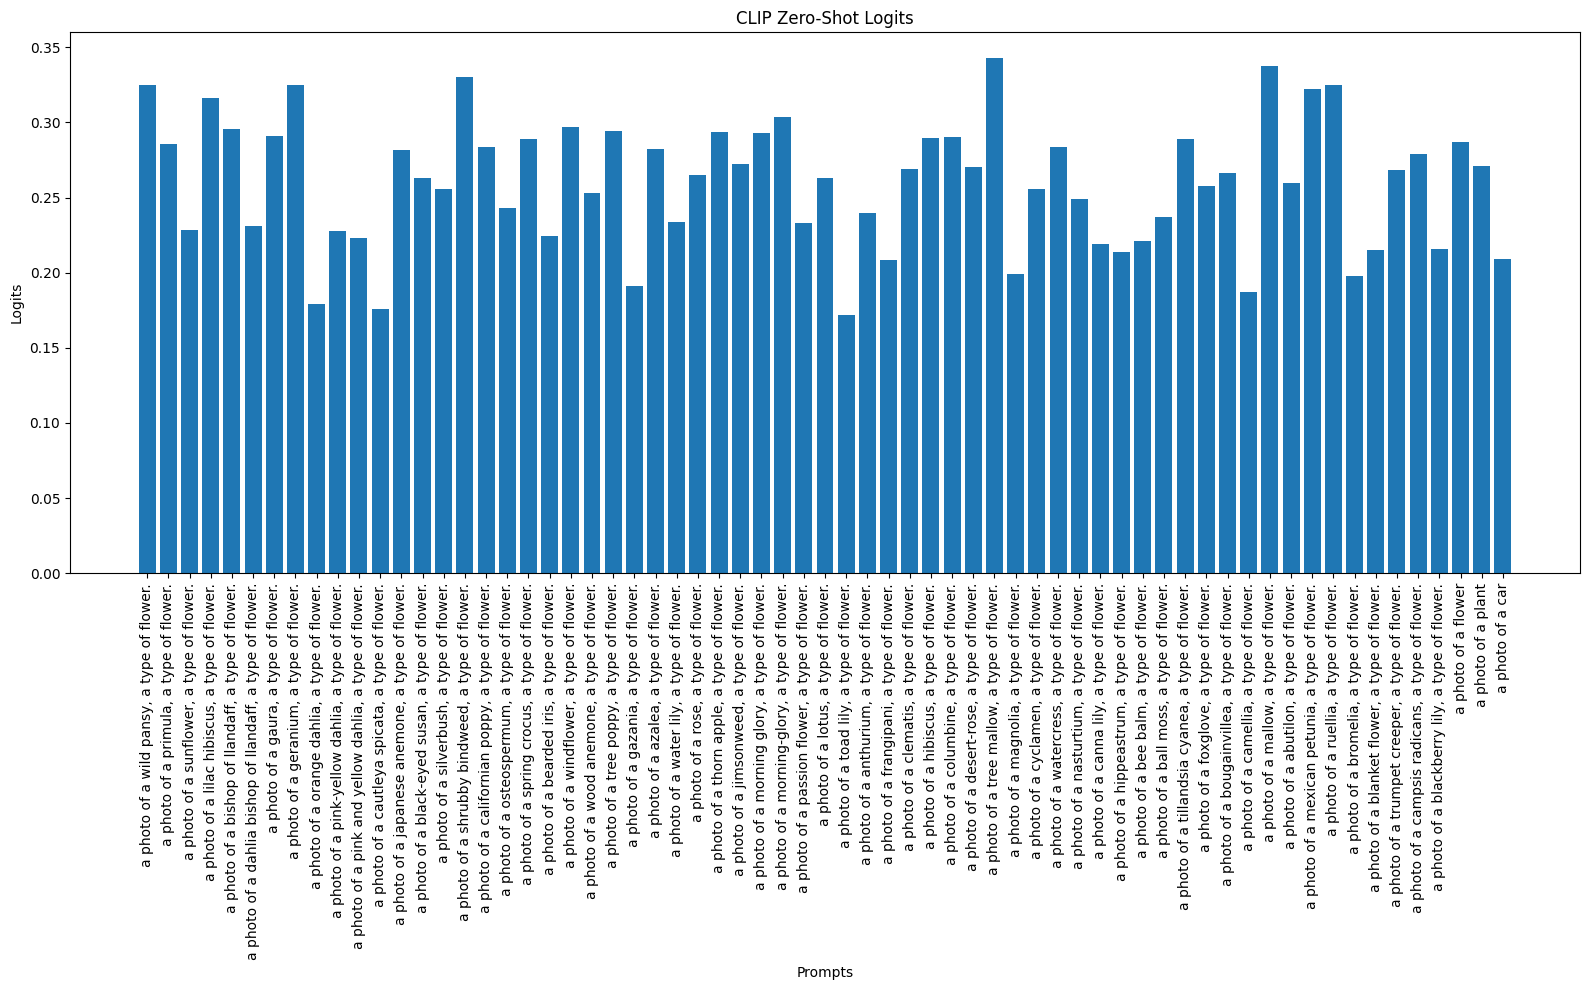

In [20]:
# plot data as histogram
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(max(12, len(plot_data)//4), 10))  # Increased height for taller columns
bars = ax.bar(plot_data.keys(), plot_data.values())
ax.set_xlabel("Prompts")
ax.set_ylabel("Logits")
ax.set_title("CLIP Zero-Shot Logits")
plt.xticks(rotation=90)  # Rotate labels vertically for readability
plt.tight_layout()
plt.show()